In [1]:
from langchain.chat_models import init_chat_model

llm=init_chat_model(model_provider="groq", model="openai/gpt-oss-120b")

In [4]:
from dotenv import load_dotenv
load_dotenv()

True

In [5]:
from langchain_community.tools.tavily_search import TavilySearchResults
tavily = TavilySearchResults()

In [6]:
tavily.invoke("attention is all you need")

[{'title': 'Attention Is All You Need',
  'url': 'https://en.wikipedia.org/wiki/Attention_Is_All_You_Need',
  'content': '"Attention Is All You Need" is a 2017 research paper in machine learning authored by eight scientists and engineers working at Google. The paper introduced a new deep learning architecture known as the transformer "Transformer (deep learning)"), based on the attention mechanism proposed in 2014 by Bahdanau et al. The transformer approach it describes has become the main architecture of a wide variety of artificial intelligence systems, including large language models. At the time, the focus of the research was on improving Seq2seq techniques for machine translation, but the authors went further in the paper, foreseeing the technique\'s potential for other tasks like question answering and what is now known as multimodal generative AI. [...] On 2017-06-12, the original (100M-parameter) encoder–decoder transformer model was published in the "Attention is all you need"

In [7]:
from langchain_core.tools import tool

@tool
def tavily_tool(query):
    """use this tool when you want to search the internet"""
    response=tavily.invoke(query)
    return response

In [10]:
from typing import TypedDict, Annotated
from langgraph.graph import add_messages

class State(TypedDict):
    messages:Annotated[list, add_messages]

In [17]:
from langchain_core.prompts import PromptTemplate

llm_with_tools=llm.bind_tools([tavily_tool])

def research_agent(state):
    query=state["messages"][-1]
    prompt=PromptTemplate.from_template(
        """You are a web and GitHub research expert.
        Use the available web search tool when you need current or external information.
        You may decide whether a tool call is necessary.
        When you have enough information, provide a concise answer with evidence.
        Query: {query}"""
    )

    chain= prompt | llm_with_tools
    response=chain.invoke({'query':query})
    return {'messages':[response]}

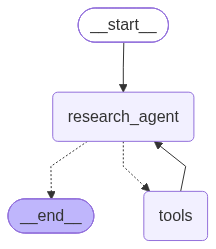

In [18]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import tools_condition, ToolNode

graph=StateGraph(State)
graph.add_node('research_agent', research_agent)
graph.add_node('tools', ToolNode([tavily_tool]))

graph.add_edge(START, "research_agent")
graph.add_conditional_edges("research_agent", tools_condition)
graph.add_edge("tools", 'research_agent')

builder=graph.compile()
builder


In [ ]:
builder.invoke({"messages":"hello"})

{'messages': [HumanMessage(content='hello', additional_kwargs={}, response_metadata={}, id='076d2d57-0d3f-4a5c-9927-6300edb9f9f0'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user: "you are a web/github research expert, given web tools answer the user query\n        Query: content=\'hello\' additional_kwargs={} response_metadata={} id=\'076d2d57-0d3f-4a5c-9927-6300edb9f9f0\'"\n\nThey want to answer the query content=\'hello\'. Probably they want to search web for "hello"? Might be ambiguous. Likely they want to find information about the term "hello". Could be code repository? The instruction: "web/github research expert". So maybe search for "hello" on GitHub? Could be a repository named hello. Use tavily search. Let\'s search web for "hello".', 'tool_calls': [{'id': 'fc_f859d8fe-448e-4c51-86b7-1fc8d4391039', 'function': {'arguments': '{"query":"hello"}', 'name': 'tavily_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 17